# Multiple Sticker Model
Based off Indei & Takimoto (2010), we're gonna implement what they did and compare it to our model. The association and dissociation rates we will have to calculate ourselves from the simulations, so we can start with getting the same plots as they generate.

We make the same assumption that the association and dissociation rates of all the stickers is the same, $\alpha, \beta$.

Check out sticky_model.ipynb for the process of constructing this model. This notebook is just for matching it to our experimental data.

## Generating $\mathbf{K}(l)$

In [92]:
import numpy as np

def recursive_K(l, alpha, beta):
    if l == 1:
        return np.array([[1, beta],[alpha, 1]])
    else:
        tl = recursive_K(l-1, alpha, beta)
        tr = beta * np.identity(2 ** (l-1))
        bl = alpha * np.identity(2 ** (l-1))
        br = recursive_K(l-1, alpha, beta)
        return np.block([[tl, tr],
                          [bl, br]])

def recursive_K_list(l, alpha_list, beta_list):
    if l == 1:
        return np.array([[1, beta_list[0]],[alpha_list[0], 1]])
    else:
        tl = recursive_K_list(l-1, alpha_list[:-1], beta_list[:-1])
        tr = beta_list[l-1] * np.identity(2 ** (l-1))
        bl = alpha_list[l-1] * np.identity(2 ** (l-1))
        br = recursive_K_list(l-1, alpha_list[:-1], beta_list[:-1])
        return np.block([[tl, tr],
                          [bl, br]])


## Generating $\mathbf W(N_a)$

In [93]:
# N_a is the total number of stickers on a chain
def generate_W(N_a, alpha, beta):
    K_N_a = recursive_K(N_a, alpha, beta)
    K_upper = np.triu(K_N_a, 1)
    K_lower = np.tril(K_N_a, -1)
    
    W_diagonal = np.diagflat(-np.sum(K_N_a, axis=0)+1)

    return K_upper + K_lower + W_diagonal

def generate_W_lists(N_a, alpha_lit, beta_list):
    if len(alpha_lit) != len(beta_list) or len(alpha_lit) != N_a:
        raise ValueError("Incorrect number of association/dissociation parameters.")
    K_N_a = recursive_K_list(N_a, alpha_lit, beta_list)
    K_upper = np.triu(K_N_a, 1)
    K_lower = np.tril(K_N_a, -1)
    
    W_diagonal = np.diagflat(-np.sum(K_N_a, axis=0)+1)

    return K_upper + K_lower + W_diagonal


In [94]:
def extract_n_s(s, M, N_b):
    N_a = (N_b - 1) // M + 1
    if N_a < M:
        raise ValueError("N_a must be greater than or equal to M.")
    
    n_s = np.zeros(M * (N_a-1) + 1, dtype=int)

    index = 0
    while True:
        n_s[index] = s & 1
        s = s >> 1
        if s == 0:
            break
        if index >= M * (N_a-1):
            raise ValueError(f"s is too large to fit in the specified number of stickers and spacing, s^max = {2 ** N_a - 1}.")
        index += M
    return n_s


In [95]:
# Note: negating 0 gives -1, we have to add some int() typecasts
def generate_B(s, M, N_b):
    if (N_b-1) % M != 0:
        raise ValueError("N_b-1 must be divisible by M.")
    n_s = extract_n_s(s, M, N_b)
    B = np.zeros((N_b-1, N_b-1))

    for i, pair in enumerate(zip(n_s[:-1], n_s[1:])):
        if i != 0: # a_i
            B[i, i-1] = -1 * int(pair[0]==0)
        if i != N_b - 2: # c_i
            B[i, i+1] = -1 * int(pair[1]==0)
        # b_i
        B[i, i] = (int(pair[0]==0) or int(pair[1]==0)) + (int(pair[0]==0) and int(pair[1]==0))

    return B

# Solving equations for $h_{k,l}^s, g_{k,l}^s$
We need to solve for coefficients $h_{k,l}^s, g_{k,l}^s$ governed by equation 25a
$$
- \omega h_{k,l}^s + \frac{k_b}{\zeta} \sum_{j=1}^{N_b-1}(B_{k,j}^sg_{j,l}^s + B_{l,j}^sg_{k,j}^s) = \sum_{s^\prime=0}^{s_\text{max}}W_{s^\prime, s} g_{k,l}^{s^\prime}
$$
and 25b
$$
\omega g_{k,l}^s-\omega \delta_{k,l} + \frac{k_b}{\zeta}\sum_{j=1}^{N_b-1}(B_{k,j}^sh_{j,l}^s+B_{l,j}^sh_{k,j}^s)=\sum_{s^\prime=0}^{s_\text{max}}W_{s^\prime,s}h_{k,l}^{s^\prime}
$$

In [96]:
from scipy.sparse import lil_matrix, csr_matrix, csc_matrix, coo_matrix
from scipy.sparse.linalg import LinearOperator
from time import time

"""
Linear operator form of A, does not need to store/manipulate the full matrix. Intended for use with iterative solvers like GMRES.

Uses the same indexing scheme as the full matrix, check out construct_Ab for more details.

Args:
    - x: vectorized g and h, stacked
    - omega: omega value to calculate shear dynamic moduli -- each omega value gives us one value of G' and G'' each
    - B: (s_max + 1) x (N_b - 1) x (N_b - 1) bead connectivity matrix
    - W: (s_max + 1) x (s_max + 1) association state transition matrix
    - k_b: spring constant along backbone beads
    - zeta: friction constant from Langevin equation (also dimensionless friction constant, they are interchangeable)
    - N_k: number of Kuhn steps in one chain, used if dimensionless (i.e. if k_b is none, replaces k_b)
    - N_b: number of beads in one chain
    - M: spacing of stickers
    - N_a: number of stickers in one chain (if None, is calculated)
    - s_max: maximum association state (if None, is calculated)

Returns:
    - Ax: result of applying linear operator A to vector x

"""
def A_operator(x, omega, B, W, k_b=None, zeta=1e-5, N_k=128, N_b=31, M=5, N_a=7, s_max=None):
    if N_a == None:
        N_a = (N_b - 1) // M + 1
    
    if s_max == None:
        s_max = 2**N_a - 1
    
    vectorize_length = (s_max + 1) * (N_b - 1) * (N_b - 1)

    if k_b == None:
        k_b_zeta = 3/(zeta * N_k)
    else:
        k_b_zeta = k_b/zeta


    Ax = np.zeros_like(x)

    # this is pass by reference btw
    g = x[:vectorize_length].reshape(s_max+1, N_b-1, N_b-1)
    h = x[vectorize_length:].reshape(s_max+1, N_b-1, N_b-1)

    Ax_g = Ax[:vectorize_length].reshape(s_max+1, N_b-1, N_b-1)
    Ax_h = Ax[vectorize_length:].reshape(s_max+1, N_b-1, N_b-1)

    Wg = np.tensordot(W.T, g, axes=(1,0))
    Wh = np.tensordot(W.T, h, axes=(1,0))

    BT = B.transpose(0, 2, 1)

    Bg_left = B @ g
    Bg_right = g @ BT

    Bh_left = B @ h
    Bh_right = h @ BT

    Ax_g += -omega * h + k_b_zeta * Bg_left + k_b_zeta * Bg_right - Wg
    Ax_h += omega * g + k_b_zeta * Bh_left + k_b_zeta * Bh_right - Wh

    return Ax

In [97]:
"""
Construct coupling matrix A and constant RHS b such that we can solve an equation Ax = b to get values of g, h
In this form, x is stacked vectorized g and h. Each row of A encodes an equation.
A encodes equation 25a in the first vectorize_length rows, and 25b in the second vectorize_length rows.

We additionally need B^s_{k,l} and W_{s', s} matrices. W isn't a problem, but B needs to be composed into a 
tensor for each valid value of s.

Generating with COO sparse matrix is the fastest out of what I tested.

Args:
    - omega: omega value to calculate shear dynamic moduli -- each omega value gives us one value of G' and G'' each
    - B: (s_max + 1) x (N_b - 1) x (N_b - 1) bead connectivity matrix
    - W: (s_max + 1) x (s_max + 1) association state transition matrix
    - k_b: spring constant along backbone beads
    - zeta: friction constant from Langevin equation (also dimensionless friction constant, they are interchangeable)
    - N_k: number of Kuhn steps in one chain, used if dimensionless (i.e. if k_b is none, replaces k_b)
    - N_b: number of beads in one chain
    - M: spacing of stickers
    - N_a: number of stickers in one chain (if None, is calculated)
    - s_max: maximum association state (if None, is calculated)
    - pbar: optional tqdm progress bar to update during construction (single global bar)
Returns:
    - A: matrix A encoding equations 25a and 25b to be applied to vectorized g and h.
    - b: RHS constants from equations 25a and 25b
"""
def construct_Ab(omega, B, W, k_b=None, zeta=1e-5, N_k=128, N_b=15, M=2, N_a=8, s_max=None, pbar=None, verbose=True):
    start = time()

    if N_a == None:
        N_a = (N_b - 1) // M + 1
    
    if s_max == None:
        s_max = 2**N_a - 1
    
    vectorize_length = (s_max + 1) * (N_b - 1) * (N_b - 1)

    if k_b == None:
        k_b_zeta = 3/(zeta * N_k)
        if verbose:
            print(f"Using dimensionless k_b = 1/N_k = {1/N_k}, zeta = {zeta}, so k_b/zeta = {k_b_zeta}")
    else:
        k_b_zeta = k_b/zeta
        if verbose:
            print(f"Using k_b = {k_b}, zeta = {zeta}, so k_b/zeta = {k_b_zeta}")

    b = np.zeros((2 * vectorize_length, 1))

    for s in range(s_max + 1):
        for k in range (1, N_b):
            for l in range (1, N_b):
                # for 25b, b = \omega \delta_{k,l}
                if k == l:
                    b[(s_max+1)*(N_b-1)**2 + s*(N_b-1)**2 + (k-1)*(N_b-1) + (l-1), 0] += omega
    A = LinearOperator((2 * vectorize_length, 2 * vectorize_length), matvec=lambda x: A_operator(x, omega, B, W, k_b=k_b, zeta=zeta, N_k=N_k, N_b=N_b, M=M, N_a=N_a, s_max=s_max))
    # print(f"Constructed A and b in {time() - start:.2f} seconds.")
    
    return A, b




In [98]:
"""
Constructs preconditioner P that approximates **A inverse** ($P \approx A^{-1}$), using Jacobi preconditioner. We take the diagonal of A and invert it, as a linear operator.
Takes the same arguments as A_operator because it's pretty much the same, just only constructing the diagonal then taking the inverse.

It doesn't need the some of these arguments, but we keep them for consistency and laziness.

Args:
    - x: vectorized g and h, stacked
    - omega: omega value to calculate shear dynamic moduli -- each omega value gives us one value of G' and G'' each
    - B: (s_max + 1) x (N_b - 1) x (N_b - 1) bead connectivity matrix
    - W: (s_max + 1) x (s_max + 1) association state transition matrix
    - k_b: spring constant along backbone beads
    - zeta: friction constant from Langevin equation (also dimensionless friction constant, they are interchangeable)
    - N_k: number of Kuhn steps in one chain, used if dimensionless (i.e. if k_b is none, replaces k_b)
    - N_b: number of beads in one chain
    - M: spacing of stickers
    - N_a: number of stickers in one chain (if None, is calculated)
    - s_max: maximum association state (if None, is calculated)

Returns:
    - Px: result of applying linear operator P to vector x

"""
def P_operator(x, omega, B, W, k_b=None, zeta=1e-5, N_k=128, N_b=31, M=5, N_a=7, s_max=None):
    if N_a == None:
        N_a = (N_b - 1) // M + 1

    if s_max == None:
        s_max = 2**N_a - 1

    vectorize_length = (s_max + 1) * (N_b - 1) * (N_b - 1)

    Px = np.zeros_like(x)

    # this is pass by reference btw
    g = x[:vectorize_length].reshape(s_max+1, N_b-1, N_b-1)
    h = x[vectorize_length:].reshape(s_max+1, N_b-1, N_b-1)

    Px_g = Px[:vectorize_length].reshape(s_max+1, N_b-1, N_b-1)
    Px_h = Px[vectorize_length:].reshape(s_max+1, N_b-1, N_b-1)

    Px_g += -(1/omega) * h # 1/omega for inverse
    Px_h += (1/omega) * g

    return Px

In [99]:
def construct_P(omega, B, W, k_b=None, zeta=1e-5, N_k=128, N_b=15, M=2, N_a=8, s_max=None, pbar=None, verbose=True):

    if N_a == None:
        N_a = (N_b - 1) // M + 1
    
    if s_max == None:
        s_max = 2**N_a - 1
    
    vectorize_length = (s_max + 1) * (N_b - 1) * (N_b - 1)

    P = LinearOperator((2 * vectorize_length, 2 * vectorize_length), matvec=lambda x: P_operator(x, omega, B, W, k_b=k_b, zeta=zeta, N_k=N_k, N_b=N_b, M=M, N_a=N_a, s_max=s_max))
    
    return P

In [100]:
def B_tensor(M=2, N_b=15):
    N_a = (N_b - 1) // M + 1
    s_max = 2**N_a - 1
    B = np.zeros((s_max + 1, N_b-1, N_b-1))
    for s in range(2**N_a):
        B_mat = generate_B(s=s, M=M, N_b=N_b)
        B[s] = B_mat
    return B
# B_tensor()


In [101]:
def count_associated(s, M=2, N_b=15):
    return np.sum(extract_n_s(s, M, N_b))

# n_c is density of chains
def nu_s(s, alpha, beta, M, N_b, n_c=1):
    N_a = (N_b - 1) // M + 1
    N_s = count_associated(s, M, N_b)
    return alpha**N_s * beta**(N_a - N_s) / (alpha + beta)**N_a * n_c
    

def dynamic_shear_moduli(x, alpha, beta, s_max, M, N_b, k_B=1, T=1, n_c=1):
    length = len(x)//2

    g = np.reshape(x[:length], (s_max+1, N_b-1, N_b-1))
    h = np.reshape(x[length:], (s_max+1, N_b-1, N_b-1))

    G_p = 0
    G_pp = 0 
    for s in range(s_max+1):
        for k in range(N_b-1):
            G_p += k_B*T* nu_s(s, alpha, beta, M, N_b, n_c)*g[s, k, k]
            G_pp += k_B*T* nu_s(s, alpha, beta, M, N_b, n_c)*h[s, k, k]

    return G_p, G_pp


In [102]:
from tqdm.notebook import tqdm
from scipy.sparse.linalg import spsolve, lgmres, gmres
from joblib import Parallel, delayed
from time import time
from threadpoolctl import threadpool_limits

def solve_omega(omega, thread_limit=2, alpha=1, beta=1, k_b=1.72, zeta=25, N_k=None, N_b=31, N_a=7, M=5, n_c=0.0274, verbose=True, x0=None):
    s_max = 2**N_a - 1

    # generating matrices
    B = B_tensor(M=M, N_b=N_b)
    W = generate_W(N_a=N_a, alpha=alpha, beta=beta)

    # print("Condition number of W:", np.linalg.cond(W))
    # print("First 10 eigenvalues of W:", np.linalg.eigvals(W)[:10])

    with threadpool_limits(limits=thread_limit):
        start = time()
        A, b = construct_Ab(omega, B, W, k_b=k_b, zeta=zeta, N_k=N_k, N_b=N_b, M=M, N_a=N_a, s_max=s_max, verbose=verbose)
        P = construct_P(omega, B, W, k_b=k_b, zeta=zeta, N_k=N_k, N_b=N_b, M=M, N_a=N_a, s_max=s_max)
        # print("Matrix constructed.")

        x, info = lgmres(A, b, x0=x0, maxiter=10000)
        # x, info = gmres(A, b, x0=x0, callback=lambda pr_norm: print(f"GMRES residual norm: {pr_norm}"), callback_type='legacy')

        if info != 0:
            if verbose:
                print(f"LGMRES did not converge, info = {info}, trying again GMRES")
            x, info = gmres(A, b, x0=x0, callback=lambda pr_norm: print(f"GMRES residual norm: {pr_norm}"), callback_type='legacy')
        x0 = x  # Update x0 for the next iteration (whichever one that is, not necessarily the next omega exactly)
        if verbose:
            print("Solved for x w/ LGMRES")
        assert info == 0, f"Did not converge, info = {info}"
        
        G_p, G_pp = dynamic_shear_moduli(x, alpha=alpha, beta=beta, s_max=s_max, M=M, N_b=N_b, k_B=1, T=1, n_c=n_c)
        if verbose:
            print(f"Omega: {omega:.4f}, G_p: {G_p:.4f}, G_pp: {G_pp:.4f}, time taken: {time() - start:.2f} seconds")

        return omega, G_p, G_pp, x


In [103]:
def solve_spectrum(omegas, n_jobs=10, thread_limit=2, alpha=1, beta=1, k_b=1.72, zeta=25, N_k=None, N_b=31, N_a=7, M=5, n_c=0.0274, verbose=True, x0=None):
    results = Parallel(n_jobs=n_jobs)(
        delayed(solve_omega)(thread_limit=thread_limit, omega=omega, alpha=alpha, beta=beta, k_b=k_b, zeta=zeta, N_k=N_k, N_b=N_b, N_a=N_a, M=M, n_c=n_c, verbose=verbose, x0=x0) for omega in omegas
    )
    
    results_sorted = sorted(results, key=lambda t: t[0])

    # unpack
    omegas, G_p_list, G_pp_list, x0_list = zip(*results_sorted)

    # convert to numpy arrays, faster for plotting/processing
    omegas = np.array(omegas)
    G_p_list = np.array(G_p_list)
    G_pp_list = np.array(G_pp_list)

    return omegas, G_p_list, G_pp_list, x0_list

In [104]:
# N_k = 128
# zeta_tilde = 1e-5
# N_b = 15

# t_rouse = N_k * zeta_tilde * N_b**2 / np.pi**2
# print("Rouse time:", t_rouse)

## quick test

In [105]:
import numpy as np

# physical chain parameters
N_b = 31
N_a = 7
M = 5
s_max = 2**N_a - 1

# calculation parameters
omega = 1
k_b = 1
zeta = 1

vectorize_length = (N_b - 1) * (N_b - 1) * (s_max + 1)

# vectorize h, k --> goes from (N_b - 1) x (N_b - 1) x (s_max + 1) to (N_b - 1) * (N_b - 1) * (s_max + 1) x 1
g = np.zeros(vectorize_length)
h = np.zeros(vectorize_length)

x = np.concatenate((g,h))
# grouped like l, then k, then s -> N_b - 1 elements along axis l, then N_b - 1 of those for axis k, then s_max + 1 of those for axis s. 

"""
Convert indices s, k, l to index of vectorized g. 
note that k,l indices are 1-based, hence (index-1), but s is 0-based

In the vector x (concatenate g and h) g comes first.

Args:
    - s: s index, in [1, s_{max} + 1]
    - k: k index, in [1, N_b - 1]
    - l: l index, in [1, N_b - 1]
    - s_max: maximum association state
    - N_b: number of beads

Returns: 
    - index along vectorized g vector
"""
def g_index(s, k, l, s_max, N_b):
    return s*(N_b-1)**2 + (k-1)*(N_b-1) + (l-1)

"""
Convert indices s, k, l to index of vectorized h. 
note that k,l indices are 1-based, hence (index-1), but s is 0-based

In the vector x (concatenate g and h) h comes second, offset by (N_b-1) * (N_b-1) * (s_max+1)

Args:
    - s: s index, in [1, s_{max} + 1]
    - k: k index, in [1, N_b - 1]
    - l: l index, in [1, N_b - 1]
    - s_max: maximum association state
    - N_b: number of beads

Returns: 
    - index along vectorized g vector
"""
def h_index(s, k, l, s_max, N_b):
    # print((s_max+1))
    # print((N_b-1))
    # print((s_max+1)*(N_b-1)**2 + s*(N_b-1)**2 + (k-1)*(N_b-1) + (l-1))
    return (s_max+1)*(N_b-1)**2 + s*(N_b-1)**2 + (k-1)*(N_b-1) + (l-1)


from scipy.sparse import lil_matrix, csr_matrix, csc_matrix, coo_matrix
from time import time
"""
Construct coupling matrix A and constant RHS b such that we can solve an equation Ax = b to get values of g, h
In this form, x is stacked vectorized g and h. Each row of A encodes an equation.
A encodes equation 25a in the first vectorize_length rows, and 25b in the second vectorize_length rows.

We additionally need B^s_{k,l} and W_{s', s} matrices. W isn't a problem, but B needs to be composed into a 
tensor for each valid value of s.

Generating with COO sparse matrix is the fastest out of what I tested.

Args:
    - omega: omega value to calculate shear dynamic moduli -- each omega value gives us one value of G' and G'' each
    - B: (s_max + 1) x (N_b - 1) x (N_b - 1) bead connectivity matrix
    - W: (s_max + 1) x (s_max + 1) association state transition matrix
    - k_b: spring constant along backbone beads
    - zeta: friction constant from Langevin equation (also dimensionless friction constant, they are interchangeable)
    - N_k: number of Kuhn steps in one chain, used if dimensionless (i.e. if k_b is none, replaces k_b)
    - N_b: number of beads in one chain
    - M: spacing of stickers
    - N_a: number of stickers in one chain (if None, is calculated)
    - s_max: maximum association state (if None, is calculated)
    - pbar: optional tqdm progress bar to update during construction (single global bar)
Returns:
    - A: matrix A encoding equations 25a and 25b to be applied to vectorized g and h.
    - b: RHS constants from equations 25a and 25b
"""
def construct_Ab_sparse(omega, B, W, k_b=None, zeta=1e-5, N_k=128, N_b=15, M=2, N_a=8, s_max=None, pbar=None):
    start = time()

    if N_a == None:
        N_a = (N_b - 1) // M + 1
    
    if s_max == None:
        s_max = 2**N_a - 1
    
    vectorize_length = (s_max + 1) * (N_b - 1) * (N_b - 1)

    # A = coo_matrix((2 * vectorize_length, 2 * vectorize_length)) # sized to be the same as x
    # b = coo_matrix((2 * vectorize_length, 1))

    # print("Shape A:", np.shape(A))
    # print("Shape b:", np.shape(b))
    # print("Shape B:", np.shape(B))
    # print("Shape W:", np.shape(W))

    if k_b == None:
        k_b_zeta = 3/(zeta * N_k)
        print(f"Using dimensionless k_b = 1/N_k = {1/N_k}, zeta = {zeta}, so k_b/zeta = {k_b_zeta}")
    else:
        k_b_zeta = k_b/zeta
        print(f"Using k_b = {k_b}, zeta = {zeta}, so k_b/zeta = {k_b_zeta}")

    rows = []
    cols = []
    data = []

    b_rows = []
    b_cols = []
    b_data = []
    

    for s in range(s_max+1):
        for k in range (1, N_b):
            for l in range (1, N_b):
                # print(f"{s} {k} {l}")
                # ---------------------------------------------
                # eqn. 25a
                # ---------------------------------------------
                row = g_index(s, k, l, s_max, N_b)

                rows.append(row)
                cols.append(h_index(s, k, l, s_max, N_b))
                data.append(-omega) # -\omega h_{k,l}^s
                # A[row, h_index(s, k, l, s_max, N_b)] += -omega # -\omega h_{k,l}^s
                
                # + \frac{k_b}{\zeta} \sum_{j=1}^{N_b-1}(B_{k,j}^sg_{j,l}^s + B_{l,j}^sg_{k,j}^s)
                for j in range(1, N_b): # j from 1 to N_b - 1
                    rows.append(row)
                    cols.append(g_index(s, j, l, s_max, N_b))
                    data.append(k_b_zeta * B[s, k-1, j-1])
                    rows.append(row)
                    cols.append(g_index(s, k, j, s_max, N_b))
                    data.append(k_b_zeta * B[s, l-1, j-1])
                    # A[row, g_index(s, j, l, s_max, N_b)] += k_b_zeta * B[s, k-1, j-1] # again, k and l are 1-based indices
                    # A[row, g_index(s, k, j, s_max, N_b)] += k_b_zeta * B[s, l-1, j-1]

                # - \sum_{s^\prime=0}^{s_\text{max}}W_{s^\prime, s} g_{k,l}^{s^\prime}
                for s_i in range(s_max + 1): # s_i from 0 to s_max
                    rows.append(row)
                    cols.append(g_index(s_i, k, l, s_max, N_b))
                    data.append(-W[s_i, s])
                    # A[row, g_index(s_i, k, l, s_max, N_b)] += -W[s_i, s] # but s is 0-based index

                # for 25a, b = 0
                # update global progress bar (one unit per (s,k,l) processed for eqn 25a)
                if pbar is not None:
                    pbar.update(1)
    
    # restart loop -- we want to be writing second half of A AFTER first half to take advantage of lil_matrix
    for s in range(s_max + 1):
        for k in range (1, N_b):
            for l in range (1, N_b):
                # ---------------------------------------------
                # eqn. 25b
                # ---------------------------------------------
                row = h_index(s, k, l, s_max, N_b)

                rows.append(row)
                cols.append(g_index(s, k, l, s_max, N_b))
                data.append(omega) # \omega g_{k,l}^s
                # A[row, g_index(s, k, l, s_max, N_b)] += omega # \omega g_{k,l}^s
                
                # + \frac{k_b}{\zeta}\sum_{j=1}^{N_b-1}(B_{k,j}^sh_{j,l}^s+B_{l,j}^sh_{k,j}^s)
                for j in range(1, N_b):
                    rows.append(row)
                    cols.append(h_index(s, j, l, s_max, N_b))
                    data.append(k_b_zeta * B[s, k-1, j-1])
                    rows.append(row)
                    cols.append(h_index(s, k, j, s_max, N_b))
                    data.append(k_b_zeta * B[s, l-1, j-1])
                    # A[row, h_index(s, j, l, s_max, N_b)] += k_b_zeta * B[s, k-1, j-1]
                    # A[row, h_index(s, k, j, s_max, N_b)] += k_b_zeta * B[s, l-1, j-1]

                # - \sum_{s^\prime=0}^{s_\text{max}}W_{s^\prime, s} h_{k,l}^{s^\prime}
                for s_i in range(s_max + 1): # s_i from 0 to s_max
                    rows.append(row)
                    cols.append(h_index(s_i, k, l, s_max, N_b))
                    data.append(-W[s_i, s])
                    # A[row, h_index(s_i, k, l, s_max, N_b)] += -W[s_i, s]

                # for 25b, b = \omega \delta_{k,l}
                if k == l:
                    b_rows.append(h_index(s, k, l, s_max, N_b))
                    b_cols.append(0)
                    b_data.append(omega)
                    # b[h_index(s, k, l, s_max, N_b),0] += omega

                # update global progress bar (one unit per (s,k,l) processed for eqn 25b)
                if pbar is not None:
                    pbar.update(1)

    end = time()
    print(f"Finished constructing entries in {end - start:.2f} seconds")
    start = end

    A = coo_matrix((data, (rows, cols)), (2 * vectorize_length, 2 * vectorize_length)) # sized to be the same as x
    b = coo_matrix((b_data, (b_rows, b_cols)),(2 * vectorize_length, 1))

    A.eliminate_zeros()
    b.eliminate_zeros()

    A.sum_duplicates()
    b.sum_duplicates()

    end = time()
    print(f"Finished summing duplicates/eliminating zeros in {end - start:.2f} seconds")
    start = end

    return A.tocsc(), b.tocsc()

In [106]:
N_b = 5
N_a = 3
M = 2

alpha = 100
beta = 0.1
omega = 1.0

s_max = 2**N_a - 1

B = B_tensor(M=M, N_b=N_b)
W = generate_W(N_a=N_a, alpha=alpha, beta=beta)

A_sparse, b = construct_Ab_sparse(
    omega,
    B,
    W,
    k_b=1.72,
    zeta=25,
    N_b=N_b,
    N_a=N_a,
    M=M,
    s_max=s_max,
)

A_lin, _ = construct_Ab(
    omega,
    B,
    W,
    k_b=1.72,
    zeta=25,
    N_b=N_b,
    N_a=N_a,
    M=M,
    s_max=s_max,
)

Using k_b = 1.72, zeta = 25, so k_b/zeta = 0.0688
Finished constructing entries in 0.00 seconds
Finished summing duplicates/eliminating zeros in 0.00 seconds
Using k_b = 1.72, zeta = 25, so k_b/zeta = 0.0688


In [107]:
from scipy.sparse.linalg import aslinearoperator
from numpy.linalg import norm


vectorize_length = (N_b - 1) * (N_b - 1) * (s_max + 1)


x_test = np.random.rand(2*vectorize_length)

y_sparse = A_sparse @ x_test
y_lin = A_lin @ x_test

print(norm(y_sparse-y_lin))

2.440408856775408e-13


In [108]:
alpha=0
beta=0.1
omega=1

solve_omega(omega=omega, thread_limit=2, alpha=alpha, beta=beta, k_b=1.72, zeta=25, N_k=None, N_b=31, N_a=7, M=5, n_c=0.0274, verbose=True, x0=None)

Using k_b = 1.72, zeta = 25, so k_b/zeta = 0.0688
Solved for x w/ LGMRES
Omega: 1.0000, G_p: 0.7458, G_pp: 0.1921, time taken: 0.30 seconds


(1,
 np.float64(0.7457847680396165),
 np.float64(0.19211769254354677),
 array([ 0.91798519,  0.06167819, -0.01153884, ..., -0.0104061 ,
        -0.11924615,  0.13326086], shape=(230400,)))

In [109]:
import pandas as pd
A_lifetime_offtime_list = [(80,    np.inf,    10.0)] # only A=80 for comparing to Rouse
# A_lifetime_offtime_list = [(80,    7.27,    5.60), 
#                            (80,   14.65,    1.02)] # only A=80 for comparing to Rouse
# A_lifetime_offtime_list = [(80,    7.27,    5.60), 
#                            (80,   14.65,    1.02), 
#                            (90,   10.38,   16.65), 
#                            (90,   16.35,    1.66), 
#                            (100,  16.79,   55.33), 
#                            (100,  29.40,    6.99),
#                            (110,  28.19,  190.89), 
#                            (110,  70.54,   21.67), 
#                            (120,  36.24,  774.71), 
#                            (120, 142.14,   81.39), 
#                            (130,  50.43, 3646.96), 
#                            (130, 184.95,  386.61)]

for A, lifetime, offtime in A_lifetime_offtime_list:
    alpha = np.round(1 / lifetime, decimals=4)
    beta = np.round(1 / offtime, decimals=4)
    omegas = np.logspace(-4, 2, 20)
    omegas_scheduler = np.zeros(20)
    omegas_scheduler[:10] = omegas[:10]
    omegas_scheduler[10:] = omegas[:9:-1]
    # print(omegas_scheduler)
    G_p_list, G_pp_list = solve_spectrum(omegas_scheduler, n_jobs=1, thread_limit=2, alpha=alpha, beta=beta, N_b=31, N_a=7, M=5, n_c=0.0274)[1:3]
    df = pd.DataFrame({
        'omega': omegas,
        'G_p': G_p_list,
        'G_pp': G_pp_list
    })
    print(f"Alpha: {alpha}, Beta: {beta}")
    print("G' values:", G_p_list)
    print("G'' values:", G_pp_list)

    df.to_csv(f'data/comparison/sticky_model/Gp_Gpp_output_A_{A}_alpha_{alpha}_beta_{beta}.csv', index=False)

Using k_b = 1.72, zeta = 25, so k_b/zeta = 0.0688
Solved for x w/ LGMRES
Omega: 0.0001, G_p: 0.0001, G_pp: 0.0032, time taken: 1.62 seconds
Using k_b = 1.72, zeta = 25, so k_b/zeta = 0.0688
Solved for x w/ LGMRES
Omega: 0.0002, G_p: 0.0006, G_pp: 0.0065, time taken: 1.62 seconds
Using k_b = 1.72, zeta = 25, so k_b/zeta = 0.0688
Solved for x w/ LGMRES
Omega: 0.0004, G_p: 0.0025, G_pp: 0.0129, time taken: 1.66 seconds
Using k_b = 1.72, zeta = 25, so k_b/zeta = 0.0688
Solved for x w/ LGMRES
Omega: 0.0009, G_p: 0.0086, G_pp: 0.0233, time taken: 1.55 seconds
Using k_b = 1.72, zeta = 25, so k_b/zeta = 0.0688
Solved for x w/ LGMRES
Omega: 0.0018, G_p: 0.0208, G_pp: 0.0351, time taken: 1.56 seconds
Using k_b = 1.72, zeta = 25, so k_b/zeta = 0.0688
Solved for x w/ LGMRES
Omega: 0.0038, G_p: 0.0364, G_pp: 0.0496, time taken: 2.04 seconds
Using k_b = 1.72, zeta = 25, so k_b/zeta = 0.0688
Solved for x w/ LGMRES
Omega: 0.0078, G_p: 0.0585, G_pp: 0.0710, time taken: 1.89 seconds
Using k_b = 1.72, ze

In [113]:
import pandas as pd

paper_sticky_model_G_p_alpha_1 = pd.read_csv("data/comparison/sticky_Gp_alpha_1.csv", names=["omega", "G'"])
paper_sticky_model_G_pp_alpha_1 = pd.read_csv("data/comparison/sticky_Gpp_alpha_1.csv", names=["omega", "G''"])
my_sticky_model_moduli_alpha_1 = pd.read_csv("data/comparison/my_sticky_model_alpha_1.csv")
print(paper_sticky_model_G_p_alpha_1.head())

      omega        G'
0  0.020515  0.001256
1  0.023709  0.001674
2  0.027042  0.002182
3  0.030844  0.002837
4  0.035180  0.003688


## Comparison with Rouse model

In [114]:
zeta = 20
k_b = 1.72
k_B = 1
T = 1
b = np.sqrt(3 * k_B * T / k_b)
N = 31

tau_rouse = zeta * N**2 * b**2 / (3 * np.pi**2 * k_B * T)
print(f"Rouse time for N={N}: {tau_rouse:.4f} LJ time units")

Rouse time for N=31: 1132.2053 LJ time units


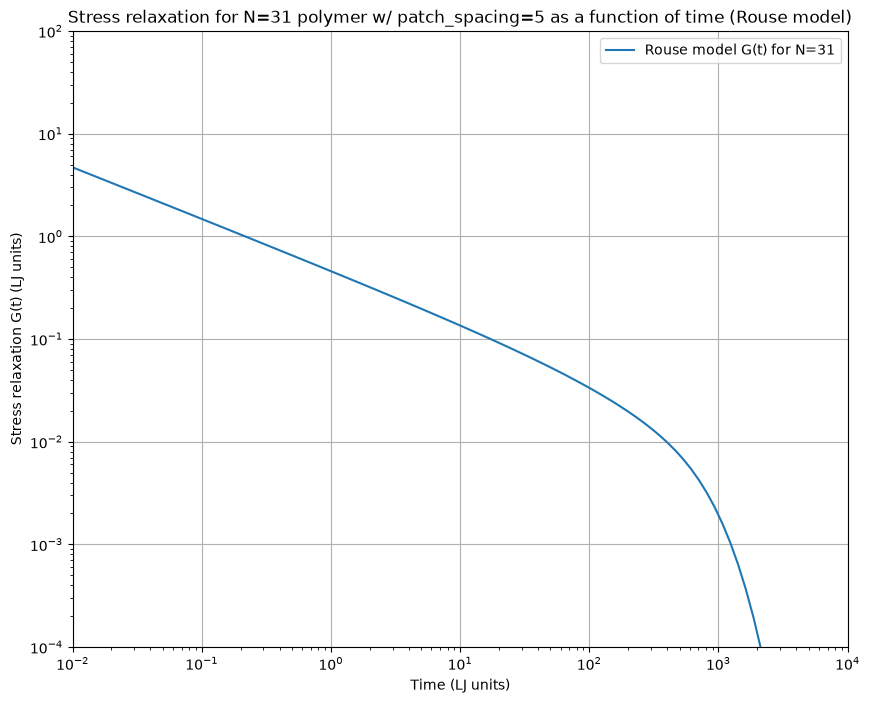

In [116]:
import matplotlib.pyplot as plt

def compute_G_t(t, tau_rouse=None, p_max=10000, c=0.0274, N=31, k_B=1.0, T=1.0, zeta=25, b=np.sqrt(3 * 1.0 * 1.0 / 1.72)):
    if tau_rouse is None:
        tau_rouse = zeta * N**2 * b**2 / (3 * np.pi**2 * k_B * T)
    G_t = 0
    for p in range(1, p_max + 1):
        G_t += np.exp(-3 * t * p**2 / tau_rouse)
    G_t *=c * k_B * T
    return G_t

t = np.logspace(-2, 4, 100)
G_t = compute_G_t(t, tau_rouse, p_max=100000)

fig = plt.figure(figsize=(10, 8))
plt.xscale('log')
plt.yscale('log')
plt.loglog(t, G_t, label='Rouse model G(t) for N=31')
plt.xlabel('Time (LJ units)')
plt.ylabel('Stress relaxation G(t) (LJ units)')
plt.xlim([1e-2, 1e4])
plt.ylim([1e-4, 1e2])
plt.grid()
plt.title('Stress relaxation for N=31 polymer w/ patch_spacing=5 as a function of time (Rouse model)')
plt.legend()
plt.show()

In [117]:
import numpy as np

def fourier_integral_moduli(t, G, omega):
    """
    Compute F(omega) = \int_0^\infty G(t) e^{-i omega t} dt
    using the discrete approximation
      sum_{k=1..N} exp(-i omega t_{k-1}) * { ... }  (as provided)
    Inputs:
      t     : 1D array of times, length M >= 2, increasing (t0..t_{M-1})
      G     : 1D array of G(t) values at those times (len == M)
      omega : scalar or 1D array of frequencies (rad/time)
    Returns:
      F    : complex array with shape (len(omega),) (or scalar if scalar omega)
      Gp   : real array G'(omega) = -omega * Im[F]
      Gpp  : real array G''(omega) =  omega * Re[F]
    Notes:
      - The formula assumes G is piecewise-defined on intervals [t_{k-1}, t_k].
      - For omega == 0 we fall back to trapezoidal integration.
    """
    t = np.asarray(t, dtype=float)
    G = np.asarray(G, dtype=float)
    if t.ndim != 1 or G.ndim != 1 or len(t) != len(G):
        raise ValueError("t and G must be 1D arrays of same length")

    omega_arr = np.atleast_1d(np.array(omega, dtype=float)) # make into a 1D array
    scalar_input = np.isscalar(omega)

    # segments: k = 1..N where N = M-1
    t_prev = t[:-1]         # t_{k-1}, shape (N,)
    dt = np.diff(t)         # Δt_k, shape (N,)
    G_prev = G[:-1]         # G_{k-1}
    G_k = G[1:]             # G_k

    if np.any(dt <= 0):
        raise ValueError("t must be strictly increasing")

    # prepare arrays for broadcasting
    W = omega_arr[:, None]          # shape (n_omega, 1)
    Tprev = t_prev[None, :]         # shape (1, N)
    DT = dt[None, :]                # shape (1, N)
    G_prev_mat = G_prev[None, :]    # shape (1, N)
    G_k_mat = G_k[None, :]          # shape (1, N)

    # handle omega == 0 separately
    # integral evaluates to simple trapezoidal integral of G(t)
    zero_mask = np.isclose(omega_arr, 0.0)
    F = np.zeros(omega_arr.shape, dtype=np.complex128)

    # 1) For zero-frequency entries use trapezoidal integral:
    if np.any(zero_mask):
        # simple trapezoid on original t/G
        F_zero = np.trapz(G, t)  # real
        F[zero_mask] = F_zero

    # 2) For non-zero omega, compute according to your discrete formula
    if np.any(~zero_mask):
        w_nz = omega_arr[~zero_mask]
        W_nz = w_nz[:, None]                 # (n_nz, 1)
        # compute exponentials
        exp_iw_dt = np.exp(-1j * W_nz * DT)  # shape (n_nz, N)
        exp_iw_tprev = np.exp(-1j * W_nz * Tprev)  # shape (n_nz, N)

        # avoid division by tiny omega^2 * dt or i*omega issues:
        # compute denominators
        w2 = (W_nz**2)            # shape (n_nz, 1)
        iw = 1j * W_nz            # shape (n_nz, 1)

        # compute the common piece (exp(-i w dt) - 1) / (w^2 dt)
        numer = (exp_iw_dt - 1.0)                     # (n_nz, N)
        denom = w2 * DT                               # (n_nz, N)
        # safe division - where denom is tiny, use Taylor expansion:
        small_mask = np.abs(denom) < 1e-16
        common = np.empty_like(numer, dtype=np.complex128)
        # safe division where denom not tiny
        ok = ~small_mask
        common[ok] = numer[ok] / denom[ok]
        # Taylor expansion for small x = w*dt: (e^{-i x}-1)/(w^2 dt)
        # numerator ~ -i x + (-x^2/2) + i(x^3/6) ...
        # (e^{-i x}-1)/(w^2 dt) ≈ (-i x - x^2/2 + ...)/(w^2 dt)
        # but x = w*dt so denominator w^2 dt = x^2/w => series simplifies;
        # The leading-order term: (-i w dt)/(w^2 dt) = -i / w
        # Next term: (- (w dt)^2/2)/(w^2 dt) = -dt/2
        # We'll use expansion up to O(dt)
        if np.any(small_mask):
            x = (W_nz * DT)[small_mask]  # small
            # compute approx: -i / w + (-DT/2) + O(w*dt)
            # note shapes align because small_mask selects elements
            approx = (-1j / W_nz[small_mask.any(axis=1)][:, None])  # shape hack - simpler compute elementwise below
            # Instead of trying to be too clever with shapes, compute elementwise fallback:
            it = np.nditer(small_mask, flags=['multi_index'])
            while not it.finished:
                i, j = it.multi_index  # i - omega index, j - segment index
                if small_mask[i, j]:
                    wval = W_nz[i, 0]
                    dtval = DT[0, j]
                    xval = wval * dtval
                    # series to O(dt)
                    common[i, j] = (-1j / wval) - 0.5 * dtval
                it.iternext()

        # compute the other denominators with iw
        # A = (exp(-i w dt) / (i w))
        # B = (1 / (i w))
        A = exp_iw_dt / (1j * W_nz)      # (n_nz, N)
        B = 1.0 / (1j * W_nz)            # (n_nz, 1) broadcasts

        # construct the bracketed expression for each segment:
        # term_k = G_k * ( common - exp(-i w dt) / (i w) )
        # minus G_{k-1} * ( common - 1/(i w) )
        term1 = G_k_mat * (common - A)
        term2 = G_prev_mat * (common - B)

        # full segment contributions (with exp(-i w t_{k-1}) factor)
        seg = exp_iw_tprev * (term1 - term2)   # shape (n_nz, N)

        # sum segments
        F_nz = np.sum(seg, axis=1)             # shape (n_nz,)
        # store back
        F[~zero_mask] = F_nz

    # final outputs: G' = -omega * Im(F), G'' = omega * Re(F)
    # ensure correct shape matching omega_arr
    Gp = -omega_arr * F.imag
    Gpp = omega_arr * F.real

    # return shapes consistent with input omega
    if scalar_input:
        return F[0], float(Gp[0]), float(Gpp[0])
    else:
        return F, Gp, Gpp


def process_dyn_moduli(data, omega=np.logspace(-5, 3, 100), cutoff=1000):
    data.dropna(inplace=True)  # drop rows with NaN values
    
    time = data['time'].values
    prepped_G_t = data['G_t'][(time > 1) & (time < cutoff)].values
    prepped_time = time[(time > 1) & (time < cutoff)]

    
    _, Gp, Gpp = fourier_integral_moduli(prepped_time, prepped_G_t, omega)

    return Gp, Gpp

<>:5: SyntaxWarning: "\i" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\i"? A raw string is also an option.
<>:5: SyntaxWarning: "\i" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\i"? A raw string is also an option.
/tmp/ipykernel_34249/2473652843.py:5: SyntaxWarning: "\i" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\i"? A raw string is also an option.
  Compute F(omega) = \int_0^\infty G(t) e^{-i omega t} dt


In [118]:
omega = np.logspace(-5, -1, 100)

rouse_Gp, rouse_Gpp = process_dyn_moduli(pd.DataFrame({'time': t, 'G_t': G_t}), omega=omega, cutoff=2000)

Current A: 80, A: 80, lifetime: inf, offtime: 10.0


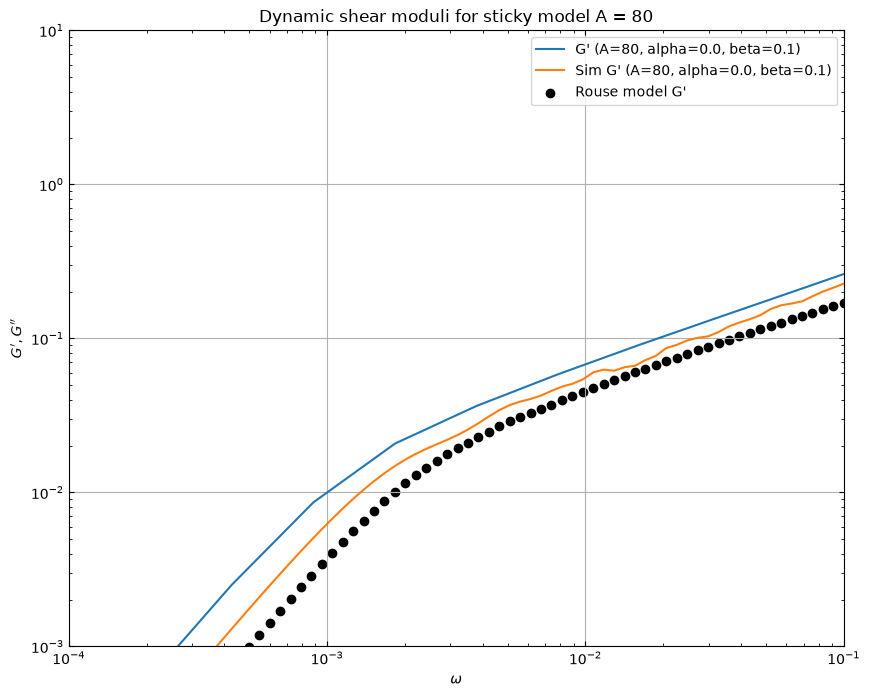

In [119]:
import matplotlib.pyplot as plt

processed_As = set()
for A, alpha, beta in A_lifetime_offtime_list:
    if A in processed_As:
        continue
    processed_As.add(A)

for current_A in sorted(processed_As):
    figure = plt.figure(figsize=(10, 8))
    for A, lifetime, offtime in A_lifetime_offtime_list:
        print(f"Current A: {current_A}, A: {A}, lifetime: {lifetime}, offtime: {offtime}")
        if A == current_A:
            alpha = np.round(1 / lifetime, decimals=4)
            beta = np.round(1 / offtime, decimals=4)
            df = pd.read_csv(f'data/comparison/sticky_model/Gp_Gpp_output_A_{A}_alpha_{alpha}_beta_{beta}.csv')
            plt.loglog(df['omega'], df['G_p'], label=f"G' (A={A}, alpha={alpha}, beta={beta})")
            
            

    try:
        sim_df = pd.read_csv(f'data/dyn_moduli/dyn_moduli_chainlength_31_patchspacing_5_N_beads_24800_gaussA_{current_A}_r0_0.25_gaussB_10_seed_12345.csv')
        plt.loglog(sim_df['omega'], sim_df['Gp'], label=f"Sim G' (A={current_A}, alpha={alpha}, beta={beta})")
    except FileNotFoundError:
        print(f"File not found for A={A}, skipping my data plot.")

    # plt.loglog(paper_sticky_model_G_p_alpha_1["omega"], paper_sticky_model_G_p_alpha_1["G'"], color='r', label="G'' (paper data)")
    # plt.loglog(paper_sticky_model_G_pp_alpha_1["omega"], paper_sticky_model_G_pp_alpha_1["G''"], color='r', linestyle='--', label="G'' (paper data)") 
    plt.scatter(omega, rouse_Gp, color='k', marker='o', label="Rouse model G'")
    plt.title(r"Dynamic shear moduli for sticky model A = 80")
    plt.xlabel(r"$\omega$")
    plt.ylabel(r"$G', G''$")
    plt.xlim(1e-4, 1e-1)
    plt.ylim(1e-3, 1e1)
    plt.tick_params(axis='both', which='both', direction='in', top=True, right=True)
    plt.legend()
    plt.grid()  
    plt.show()

Current A: 80, A: 80, lifetime: inf, offtime: 10.0


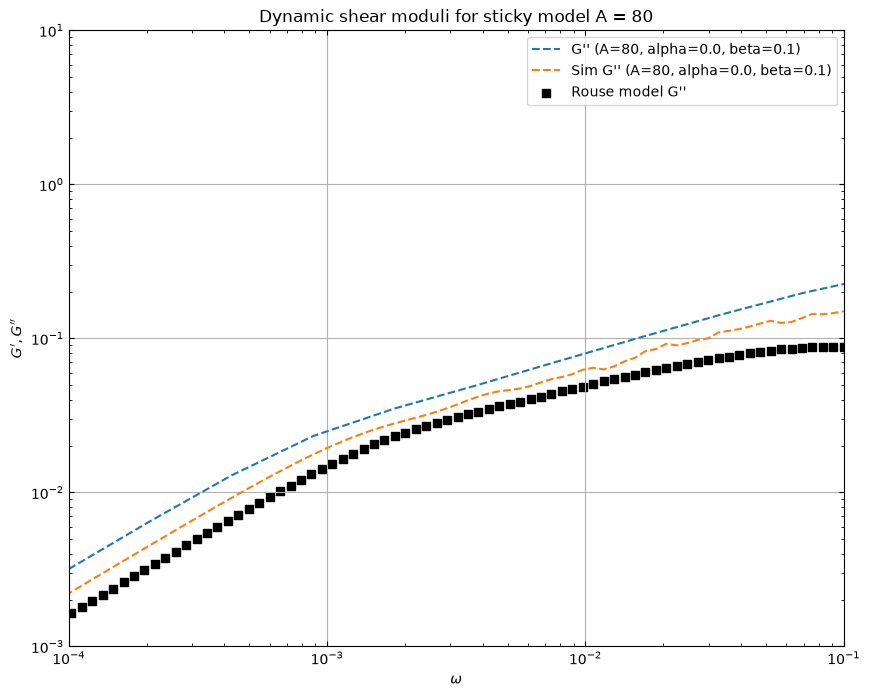

In [120]:
import matplotlib.pyplot as plt

processed_As = set()
for A, alpha, beta in A_lifetime_offtime_list:
    if A in processed_As:
        continue
    processed_As.add(A)

for current_A in sorted(processed_As):
    figure = plt.figure(figsize=(10, 8))
    for A, lifetime, offtime in A_lifetime_offtime_list:
        print(f"Current A: {current_A}, A: {A}, lifetime: {lifetime}, offtime: {offtime}")
        if A == current_A:
            alpha = np.round(1 / lifetime, decimals=4)
            beta = np.round(1 / offtime, decimals=4)
            df = pd.read_csv(f'data/comparison/sticky_model/Gp_Gpp_output_A_{A}_alpha_{alpha}_beta_{beta}.csv')
            plt.loglog(df['omega'], df['G_pp'], linestyle='--', label=f"G'' (A={A}, alpha={alpha}, beta={beta})")
            
            

    try:
        sim_df = pd.read_csv(f'data/dyn_moduli/dyn_moduli_chainlength_31_patchspacing_5_N_beads_24800_gaussA_{current_A}_r0_0.25_gaussB_10_seed_12345.csv')
        plt.loglog(sim_df['omega'], sim_df['Gpp'], linestyle='--', label=f"Sim G'' (A={current_A}, alpha={alpha}, beta={beta})")
    except FileNotFoundError:
        print(f"File not found for A={A}, skipping my data plot.")

    # plt.loglog(paper_sticky_model_G_p_alpha_1["omega"], paper_sticky_model_G_p_alpha_1["G'"], color='r', label="G'' (paper data)")
    # plt.loglog(paper_sticky_model_G_pp_alpha_1["omega"], paper_sticky_model_G_pp_alpha_1["G''"], color='r', linestyle='--', label="G'' (paper data)") 
    plt.scatter(omega, rouse_Gpp, color='k', marker='s', label="Rouse model G''")
    plt.title(r"Dynamic shear moduli for sticky model A = 80")
    plt.xlabel(r"$\omega$")
    plt.ylabel(r"$G', G''$")
    plt.xlim(1e-4, 1e-1)
    plt.ylim(1e-3, 1e1)
    plt.tick_params(axis='both', which='both', direction='in', top=True, right=True)
    plt.legend()
    plt.grid()  
    plt.show()